# Rock Paper Scissors with Convolutional Neural Network


## Experiment overview

In this experiment we will build a [Convolutional Neural Network](https://en.wikipedia.org/wiki/Convolutional_neural_network) (CNN) model using [Tensorflow](https://www.tensorflow.org/) to recognize Rock-Paper-Scissors signs (gestures) on the photo.

A **convolutional neural network** (CNN, or ConvNet) is a Deep Learning algorithm which can take in an input image, assign importance (learnable weights and biases) to various aspects/objects in the image and be able to differentiate one from the other.

![rock_paper_scissors_cnn.jpg](https://github.com/trekhleb/machine-learning-experiments/blob/master/demos/src/images/rock_paper_scissors_cnn.jpg?raw=1)

## Importing dependencies

In [ ]:
# Selecting Tensorflow version v2 (the command is relevant for Colab only).
%tensorflow_version 2.x

Colab only includes TensorFlow 2.x; %tensorflow_version has no effect.


In [ ]:
import tensorflow as tf
import tensorflow_datasets as tfds
import matplotlib.pyplot as plt
import numpy as np
import platform
import datetime
import os
import math
import random

print('Python version:', platform.python_version())
print('Tensorflow version:', tf.__version__)
print('Keras version:', tf.keras.__version__)

Python version: 3.12.13
Tensorflow version: 2.20.0
Keras version: 3.13.2


## Configuring TensorBoard

We will use TensorBoard as a helper to debug the model training process.

In [ ]:
# Load the TensorBoard notebook extension.
# %reload_ext tensorboard
%load_ext tensorboard

The tensorboard extension is already loaded. To reload it, use:
  %reload_ext tensorboard


In [ ]:
# Clear any logs from previous runs.
!rm -rf ./logs/

## Collecting your own Image Dataset

Take as many photos as you can of rock, paper, and scissors gestures. Make sure to capture them from different angles, distances, and lighting conditions to create a varied dataset. Use plain backgrounds or neutral settings to help the model focus on your hand gestures.
Avoid photos that are too blurry, too dark, or overexposed. Take multiple photos for each gesture with different angles and distances.


Organize your photos on your computer in a folder called "rock_paper_scissors_dataset", for example:


rock_paper_scissors_dataset/


    rock/
        pic1.jpg
        picd.jpg
        ...
    paper/
        pictu12341.jpg
        pic.jpg
        ...
    scissors/
        sci231.jpg
        name2.jpg
        ...

        ...

Upload the entire rock_paper_scissors_dataset folder to your Google Drive, and then copy or link your dataset folder into the Colab working directory.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
drive.mount("/content/drive", force_remount = True)

Mounted at /content/drive


In [ ]:
!mkdir /content/train

mkdir: cannot create directory ‘/content/train’: File exists


In [ ]:
!cp -r /content/drive/MyDrive/rock_paper_scissors_dataset /content/train

## Loading and preprocessing the dataset

In this section, we load images from the local directory `/content/train` where you upload your custom dataset. The code reads all image files, extracts their labels from the file names by removing trailing digits (for example, `rock77.jpg` becomes label `rock`). The resulting data is wrapped into TensorFlow datasets with efficient prefetching to optimize training performance.

In [ ]:
import os
import shutil

# path to the root folder containing class folders
dataset_dir = '/content/train/rock_paper_scissors_dataset'  # should contain subfolders: rock, paper, scissors

# go through each class folder and rename all files
for label in os.listdir(dataset_dir):
    label_path = os.path.join(dataset_dir, label)
    if not os.path.isdir(label_path):
        continue  # skip if not a folder

    for i, filename in enumerate(sorted(os.listdir(label_path))):
        file_path = os.path.join(label_path, filename)

        # skip non-image files
        if not filename.lower().endswith(('.jpg', '.jpeg', '.png')):
            continue

        # new name format: rock0.jpg, rock1.jpg, ...
        new_name = f"{label}{i}.jpg"
        new_path = os.path.join(dataset_dir, new_name)

        # move image to parent folder with new name
        os.rename(file_path, new_path)

    # remove the now-empty class folder (or non-empty if there were non-image files)
    # Use shutil.rmtree for robustness as os.rmdir only removes empty directories.
    shutil.rmtree(label_path)

In [ ]:
import os
import numpy as np
import tensorflow as tf
from sklearn.model_selection import train_test_split
from PIL import Image, UnidentifiedImageError
import re

# settings
data_dir = '/content/train/rock_paper_scissors_dataset'
crop_height, crop_width = 300, 300

from PIL import ImageOps

# function to Resize an image to fit within the target size while preserving aspect ratio
def resize_and_pad(image: Image.Image, target_size=(300, 300), background_color=(255, 255, 255)):
    # Resize while keeping aspect ratio
    image.thumbnail(target_size, Image.LANCZOS)
    # Create a white background canvas
    canvas = Image.new("RGB", target_size, background_color)
    # Paste the image at the center
    offset_x = (target_size[0] - image.width) // 2
    offset_y = (target_size[1] - image.height) // 2
    canvas.paste(image, (offset_x, offset_y))
    return np.array(canvas, dtype=np.uint8)


# load and preprocess images and labels
image_list = []
label_list = []

for filename in os.listdir(data_dir):
    if filename.lower().endswith(('.png', '.jpg', '.jpeg')):
        path = os.path.join(data_dir, filename)
        try:
            image = Image.open(path).convert('RGB')
        except (OSError, UnidentifiedImageError) as e:
            print(f"Skipping corrupted image: {path} - {e}")
            continue

        image_np = np.array(image)

        if image_np.shape[0] < crop_height or image_np.shape[1] < crop_width:
            continue

        # Reopen image for resize_and_pad to avoid issues with already loaded/closed images
        try:
            image_pil = Image.open(path).convert('RGB')
        except (OSError, UnidentifiedImageError) as e:
            print(f"Skipping corrupted image during resize: {path} - {e}")
            continue

        image_array = resize_and_pad(image_pil, target_size=(300, 300))
        image_list.append(image_array)

        # extract label by removing trailing digits from filename
        raw_label = os.path.splitext(filename)[0]
        label = re.sub(r'\d+$', '', raw_label)
        label_list.append(label)

# encode string labels to integers
unique_labels = sorted(set(label_list))
label_to_index = {label: idx for idx, label in enumerate(unique_labels)}
index_to_label = {v: k for k, v in label_to_index.items()}

def get_label_name(label_id):
    return index_to_label[label_id]

label_indices = np.array([label_to_index[label] for label in label_list], dtype=np.int64)

# convert image list to numpy array
images_array = np.array(image_list, dtype=np.uint8)

# split into training and validation sets
X_train, X_validation, y_train, y_validation = train_test_split(
    images_array, label_indices, test_size=0.2, random_state=42
)

# convert to tf.data.Dataset and shuffle
dataset_train_raw = (
    tf.data.Dataset.from_tensor_slices((X_train, y_train))
    .shuffle(buffer_size=len(X_train), seed=42)
    .prefetch(tf.data.AUTOTUNE)
)

dataset_validation_raw = (
    tf.data.Dataset.from_tensor_slices((X_validation, y_validation))
    .shuffle(buffer_size=len(X_validation), seed=42)
    .prefetch(tf.data.AUTOTUNE)
)

# print dataset structure and size
print('raw training dataset:', dataset_train_raw)
print('training set size:', len(list(dataset_train_raw)), '\n')

print('raw validation dataset:', dataset_validation_raw)
print('validation set size:', len(list(dataset_validation_raw)), '\n')

Skipping corrupted image: /content/train/rock_paper_scissors_dataset/scissors80.jpg - image file is truncated (2 bytes not processed)
Skipping corrupted image: /content/train/rock_paper_scissors_dataset/scissors81.jpg - image file is truncated (2 bytes not processed)
raw training dataset: <_PrefetchDataset element_spec=(TensorSpec(shape=(300, 300, 3), dtype=tf.uint8, name=None), TensorSpec(shape=(), dtype=tf.int64, name=None))>
training set size: 472 

raw validation dataset: <_PrefetchDataset element_spec=(TensorSpec(shape=(300, 300, 3), dtype=tf.uint8, name=None), TensorSpec(shape=(), dtype=tf.int64, name=None))>
validation set size: 119 



In [ ]:
import collections

# define a simple dataset_info object using namedtuple
DatasetInfo = collections.namedtuple("DatasetInfo", [
    "features", "splits", "num_classes", "label_names", "description"
])

dataset_info = DatasetInfo(
    features={
        "image": tf.TensorSpec(shape=(300, 300, 3), dtype=tf.uint8),
        "label": tf.TensorSpec(shape=(), dtype=tf.int64)
    },
    splits={
        "train": len(X_train),
        "validation": len(X_validation)
    },
    num_classes=len(unique_labels),
    label_names=unique_labels,
    description=f"custom dataset loaded from /content/data with {len(unique_labels)} classes."
)

# extract metadata from dataset_info
NUM_TRAIN_EXAMPLES = dataset_info.splits["train"]
NUM_VALIDATION_EXAMPLES = dataset_info.splits["validation"]
NUM_CLASSES = dataset_info.num_classes

# print summary
print('number of training examples:', NUM_TRAIN_EXAMPLES)
print('number of validation examples:', NUM_VALIDATION_EXAMPLES)
print('number of label classes:', NUM_CLASSES)

number of training examples: 472
number of validation examples: 119
number of label classes: 3


In [ ]:
dataset_info.features

{'image': TensorSpec(shape=(300, 300, 3), dtype=tf.uint8, name=None),
 'label': TensorSpec(shape=(), dtype=tf.int64, name=None)}

In [ ]:
# extract input image shape and size from dataset_info
INPUT_IMG_SHAPE_ORIGINAL = dataset_info.features['image'].shape
INPUT_IMG_SIZE_ORIGINAL = INPUT_IMG_SHAPE_ORIGINAL[0]  # assumes square image

# define reduced shape by halving original size
INPUT_IMG_SIZE_REDUCED = INPUT_IMG_SIZE_ORIGINAL // 2
INPUT_IMG_SHAPE_REDUCED = (
    INPUT_IMG_SIZE_REDUCED,
    INPUT_IMG_SIZE_REDUCED,
    INPUT_IMG_SHAPE_ORIGINAL[2]  # channel count
)

# set active input shape to reduced version
INPUT_IMG_SIZE = INPUT_IMG_SIZE_REDUCED
INPUT_IMG_SHAPE = INPUT_IMG_SHAPE_REDUCED

# print shape and size information
print('input image size (original):', INPUT_IMG_SIZE_ORIGINAL)
print('input image shape (original):', INPUT_IMG_SHAPE_ORIGINAL)
print()
print('input image size (reduced):', INPUT_IMG_SIZE_REDUCED)
print('input image shape (reduced):', INPUT_IMG_SHAPE_REDUCED)
print()
print('input image size:', INPUT_IMG_SIZE)
print('input image shape:', INPUT_IMG_SHAPE)


input image size (original): 300
input image shape (original): (300, 300, 3)

input image size (reduced): 150
input image shape (reduced): (150, 150, 3)

input image size: 150
input image shape: (150, 150, 3)


In [ ]:
print(get_label_name(0));
print(get_label_name(1));
print(get_label_name(2));

paper
rock
scissors


In [ ]:
for i in range(0,50):
  print(label_list[i])


paper
paper
paper
paper
paper
scissors
paper
paper
scissors
rock
scissors
scissors
rock
scissors
paper
rock
paper
rock
scissors
rock
scissors
scissors
scissors
rock
rock
rock
paper
paper
rock
rock
scissors
rock
rock
rock
rock
scissors
rock
scissors
scissors
paper
rock
scissors
rock
rock
paper
rock
rock
scissors
scissors
rock


## Exploring the dataset

In [ ]:
def preview_dataset(dataset):
    plt.figure(figsize=(12, 12))
    plot_index = 0
    for features in dataset.take(100):
        (image, label) = features
        plot_index += 1
        plt.subplot(10, 10, plot_index)
        # plt.axis('Off')
        label = get_label_name(label.numpy())
        plt.title('Label: %s' % label)
        plt.imshow(image.numpy())

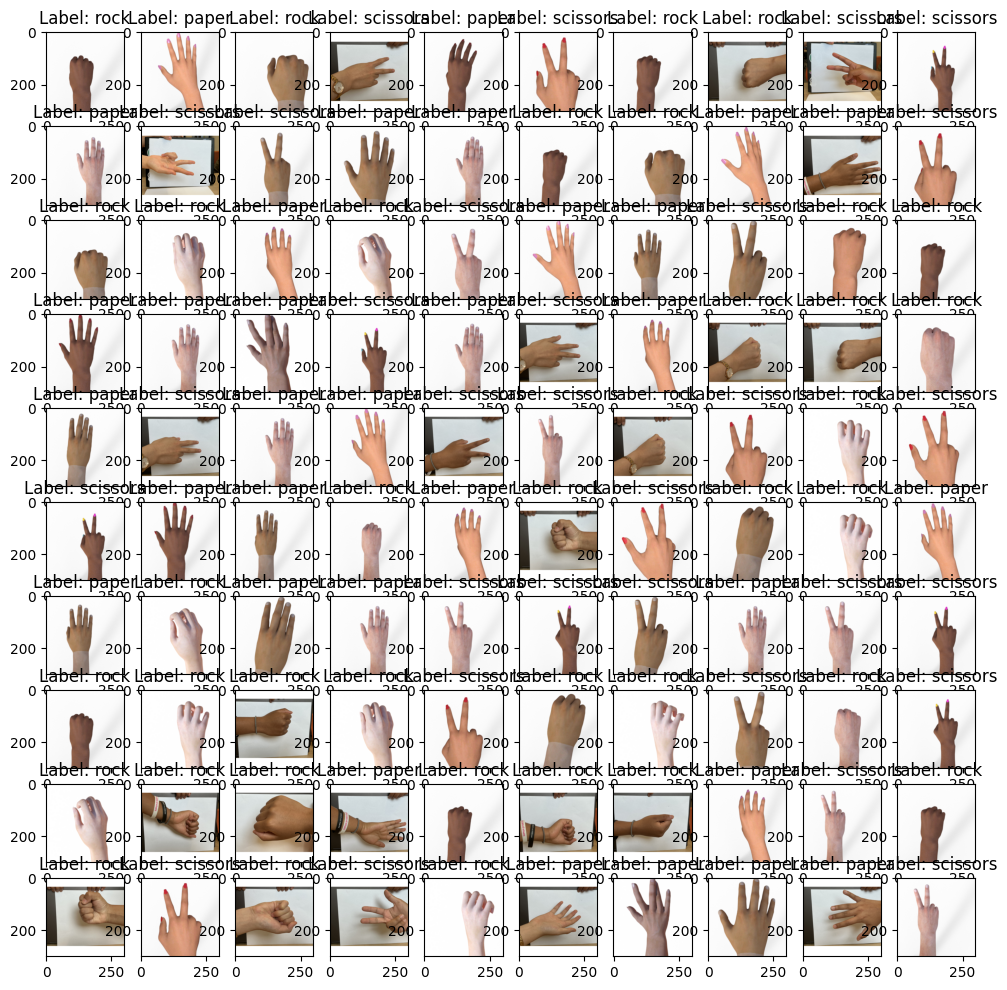

In [ ]:
# Explore raw training dataset images.
preview_dataset(dataset_train_raw)

In [ ]:
# Explore what values are used to represent the image.
(first_image, first_lable) = list(dataset_train_raw.take(1))[0]
print('Label:', first_lable.numpy(), '\n')
print('Image shape:', first_image.numpy().shape, '\n')
print(first_image.numpy())

Label: 0 

Image shape: (300, 300, 3) 

[[[253 253 253]
  [255 255 255]
  [253 253 253]
  ...
  [251 251 251]
  [248 248 248]
  [251 251 251]]

 [[254 254 254]
  [255 255 255]
  [254 254 254]
  ...
  [251 251 251]
  [251 251 251]
  [249 249 249]]

 [[254 254 254]
  [254 254 254]
  [253 253 253]
  ...
  [251 251 251]
  [251 251 251]
  [252 252 252]]

 ...

 [[251 251 251]
  [250 250 250]
  [251 251 251]
  ...
  [250 250 250]
  [251 251 251]
  [252 252 252]]

 [[252 252 252]
  [252 252 252]
  [250 250 250]
  ...
  [250 250 250]
  [251 251 251]
  [250 250 250]]

 [[250 250 250]
  [252 252 252]
  [252 252 252]
  ...
  [251 251 251]
  [252 252 252]
  [250 250 250]]]


## Pre-processing the dataset

In [ ]:
def format_example(image, label):
    # convert image to float32
    image = tf.cast(image, tf.float32)
    # normalize pixel values to [0, 1]
    image = image / 255.0
    # resize to the input size expected by the model
    image = tf.image.resize(image, [INPUT_IMG_SIZE, INPUT_IMG_SIZE])
    return image, label

In [ ]:
dataset_train = dataset_train_raw.map(format_example)
dataset_validation = dataset_validation_raw.map(format_example)

In [ ]:
# Explore what values are used to represent the image.
(first_image, first_lable) = list(dataset_train.take(1))[0]
print('Label:', first_lable.numpy(), '\n')
print('Image shape:', first_image.numpy().shape, '\n')
print(first_image.numpy())

Label: 1 

Image shape: (150, 150, 3) 

[[[0.995098   0.995098   0.995098  ]
  [0.995098   0.995098   0.995098  ]
  [0.995098   0.995098   0.995098  ]
  ...
  [0.9911765  0.9911765  0.9911765 ]
  [0.9911765  0.9911765  0.9911765 ]
  [0.9901961  0.9901961  0.9901961 ]]

 [[0.99705887 0.99705887 0.99705887]
  [0.995098   0.995098   0.995098  ]
  [0.995098   0.995098   0.995098  ]
  ...
  [0.9901961  0.9901961  0.9901961 ]
  [0.9882353  0.9882353  0.9882353 ]
  [0.9911765  0.9911765  0.9911765 ]]

 [[0.995098   0.995098   0.995098  ]
  [0.99705887 0.99705887 0.99705887]
  [0.9941176  0.9941176  0.9941176 ]
  ...
  [0.98921573 0.98921573 0.98921573]
  [0.98725486 0.98725486 0.98725486]
  [0.98921573 0.98921573 0.98921573]]

 ...

 [[0.9843137  0.9843137  0.9843137 ]
  [0.98333335 0.98333335 0.98333335]
  [0.98039216 0.98039216 0.98039216]
  ...
  [0.982353   0.982353   0.982353  ]
  [0.982353   0.982353   0.982353  ]
  [0.9813726  0.9813726  0.9813726 ]]

 [[0.9823529  0.9823529  0.9823529

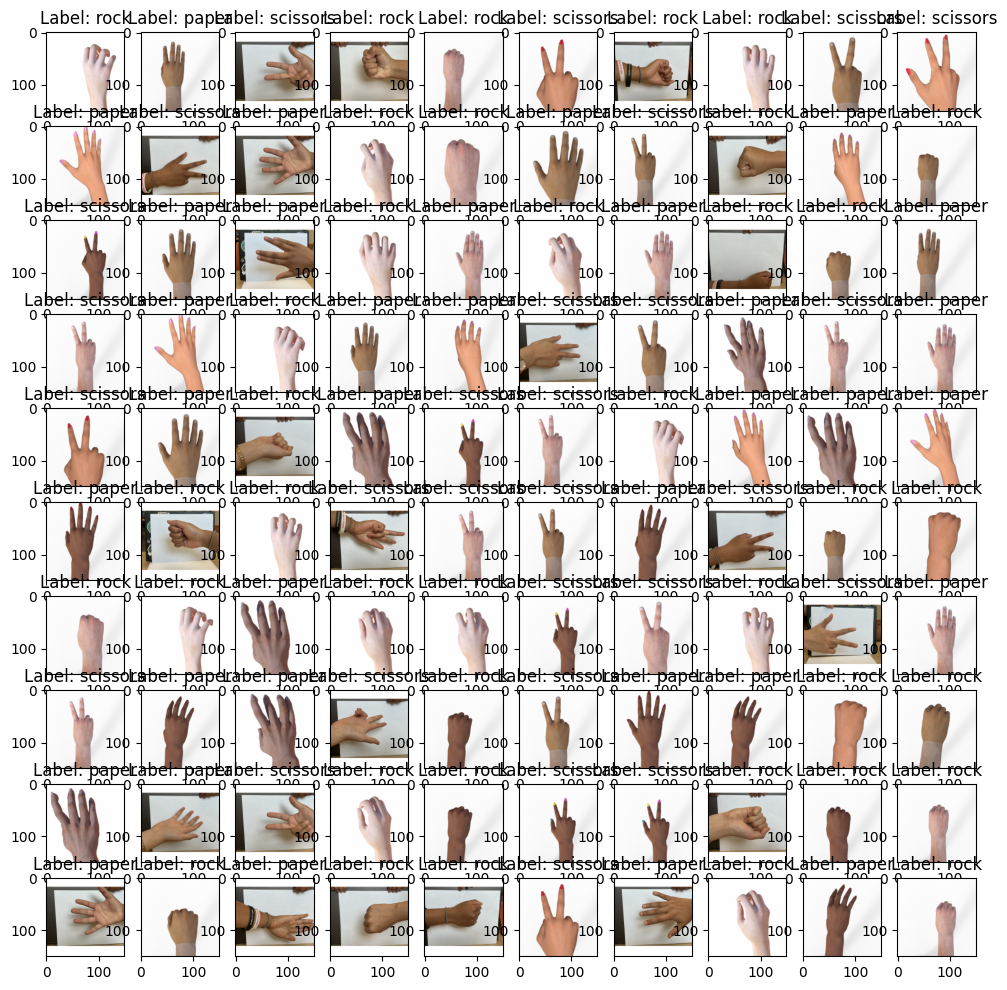

In [ ]:
# Explore preprocessed training dataset images.
preview_dataset(dataset_train)

## Creating the model

### Convolutional Neural Network Model

In [ ]:
model1 = tf.keras.models.Sequential()

# First convolution.
model1.add(tf.keras.layers.Convolution2D(
    input_shape=INPUT_IMG_SHAPE,
    filters=64,
    kernel_size=3,
    activation=tf.keras.activations.relu
))
model1.add(tf.keras.layers.MaxPooling2D(
    pool_size=(2, 2),
    strides=(2, 2)
))

# Second convolution.
model1.add(tf.keras.layers.Convolution2D(
    filters=64,
    kernel_size=3,
    activation=tf.keras.activations.relu
))
model1.add(tf.keras.layers.MaxPooling2D(
    pool_size=(2, 2),
    strides=(2, 2)
))

# Third convolution.
model1.add(tf.keras.layers.Convolution2D(
    filters=128,
    kernel_size=3,
    activation=tf.keras.activations.relu
))
model1.add(tf.keras.layers.MaxPooling2D(
    pool_size=(2, 2),
    strides=(2, 2)
))

# Fourth convolution.
model1.add(tf.keras.layers.Convolution2D(
    filters=128,
    kernel_size=3,
    activation=tf.keras.activations.relu
))
model1.add(tf.keras.layers.MaxPooling2D(
    pool_size=(2, 2),
    strides=(2, 2)
))

# Flatten the results to feed into dense layers.
model1.add(tf.keras.layers.Flatten())
model1.add(tf.keras.layers.Dropout(0.5))

# 512 neuron dense layer.
model1.add(tf.keras.layers.Dense(
    units=512,
    activation=tf.keras.activations.relu
))

# Output layer.
model1.add(tf.keras.layers.Dense(
    units=len(unique_labels),
    activation=tf.keras.activations.softmax
))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model1.summary()

Model: "sequential_12"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_24 (Conv2D)              │ (None, 148, 148, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_24 (MaxPooling2D) │ (None, 74, 74, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_25 (Conv2D)              │ (None, 72, 72, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_25 (MaxPooling2D) │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_26 (Conv2D)              │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_26 (MaxPooling2D) │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_27 (Conv2D)              │ (None, 15, 15, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_27 (MaxPooling2D) │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_12 (Flatten)            │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_32 (Dense)                │ (None, 512)            │     3,211,776 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_33 (Dense)                │ (None, 3)              │         1,539 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,473,475 (13.25 MB)

 Trainable params: 3,473,475 (13.25 MB)

 Non-trainable params: 0 (0.00 B)

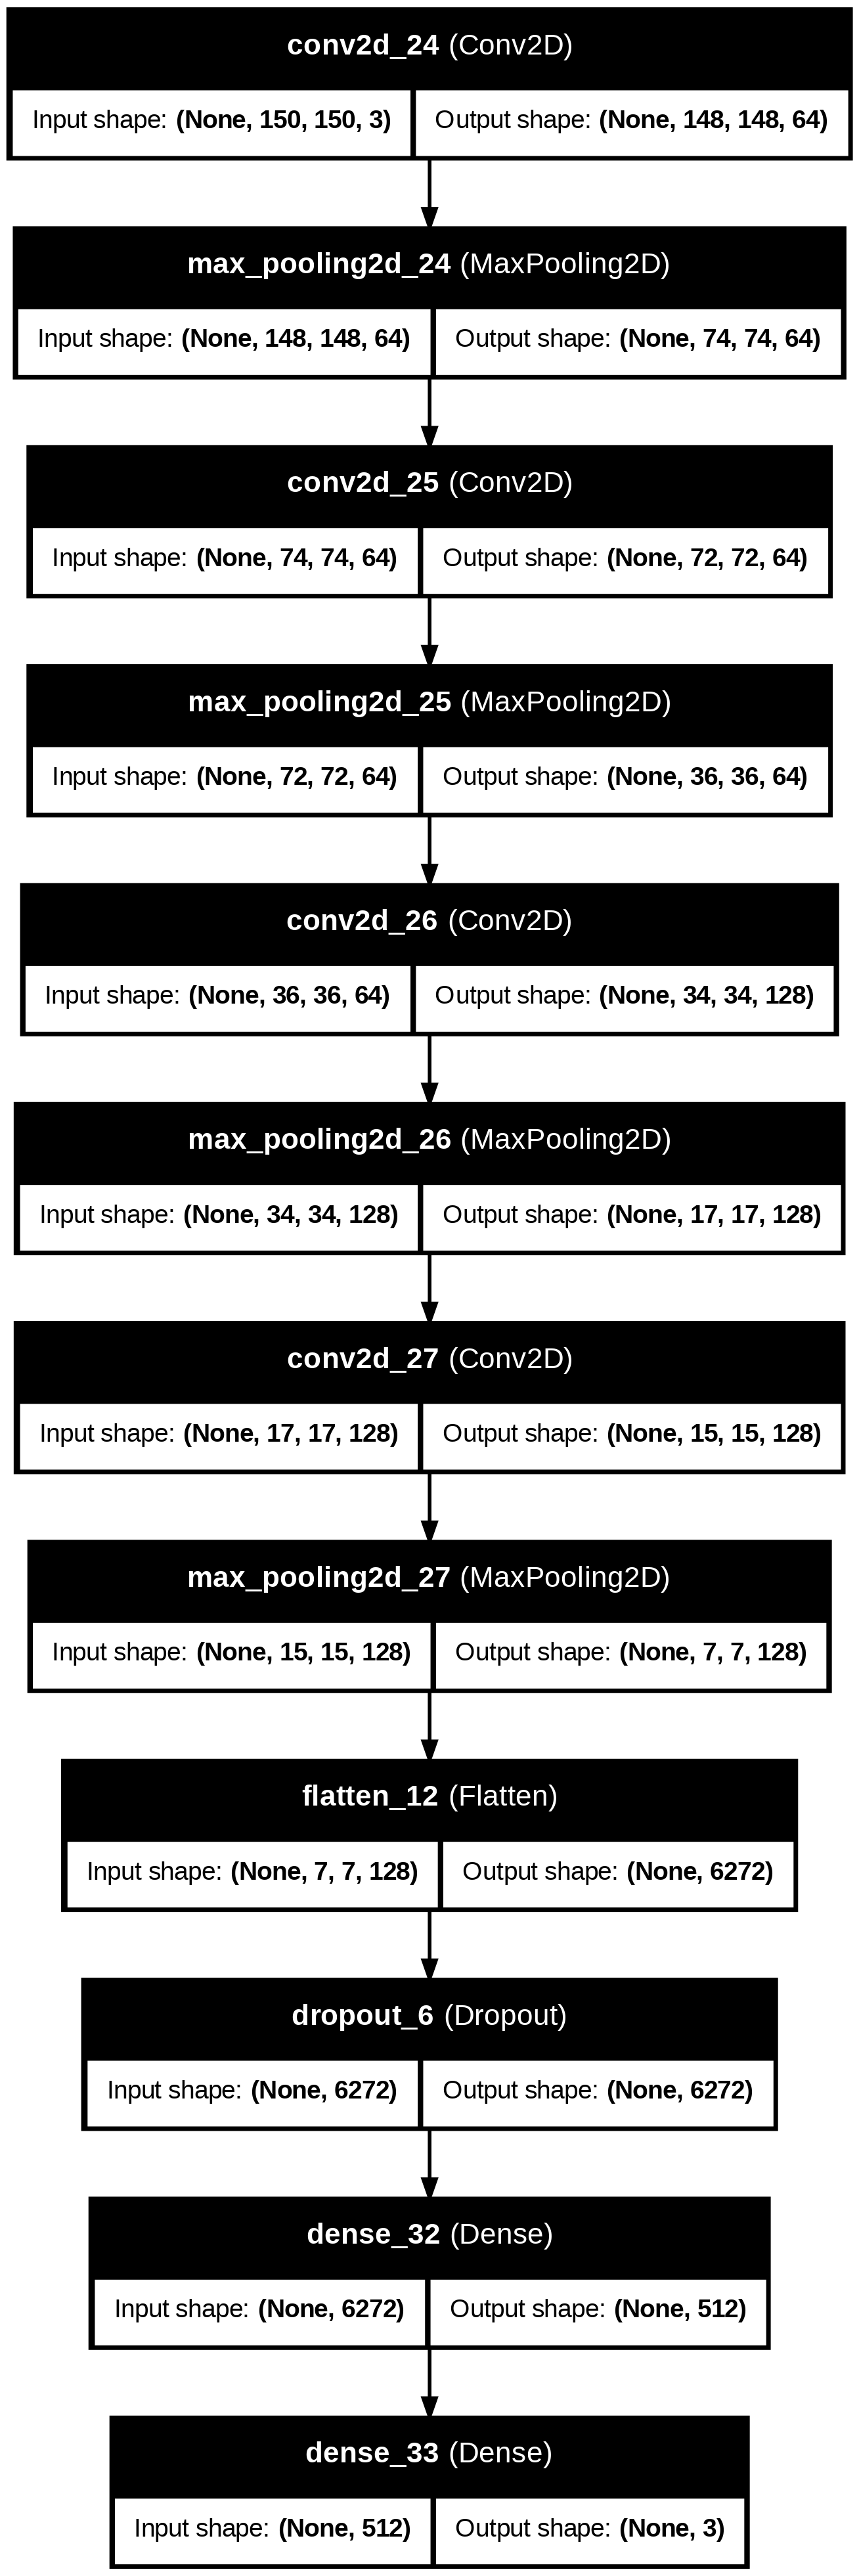

In [ ]:
tf.keras.utils.plot_model(
    model1,
    show_shapes=True,
    show_layer_names=True,
)

### Simple Neural Network Model

In [ ]:
model2 = tf.keras.models.Sequential()


## TODO: now write a code for the simple neural network model similar to what we did yesterday!

# Flatten the raw image directly into a vector (no convolutions).
model2.add(tf.keras.layers.Flatten(input_shape=INPUT_IMG_SHAPE))

# First dense (hidden) layer.
model2.add(tf.keras.layers.Dense(units=150,activation=tf.keras.activations.relu,kernel_regularizer=tf.keras.regularizers.l2(0.010)))

# Second dense (hidden) layer.
model2.add(tf.keras.layers.Dense(units=150,activation=tf.keras.activations.relu,kernel_regularizer=tf.keras.regularizers.l2(0.010)))

# Third dense (hidden) layer.
model2.add(tf.keras.layers.Dense(units=150,activation=tf.keras.activations.relu,kernel_regularizer=tf.keras.regularizers.l2(0.010)))

# Output layer.
model2.add(tf.keras.layers.Dense(units=10,activation=tf.keras.activations.softmax))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
model2.summary()

Model: "sequential_13"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_13 (Flatten)            │ (None, 67500)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_34 (Dense)                │ (None, 150)            │    10,125,150 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_35 (Dense)                │ (None, 150)            │        22,650 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_36 (Dense)                │ (None, 150)            │        22,650 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_37 (Dense)                │ (None, 10)             │         1,510 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,171,960 (38.80 MB)

 Trainable params: 10,171,960 (38.80 MB)

 Non-trainable params: 0 (0.00 B)

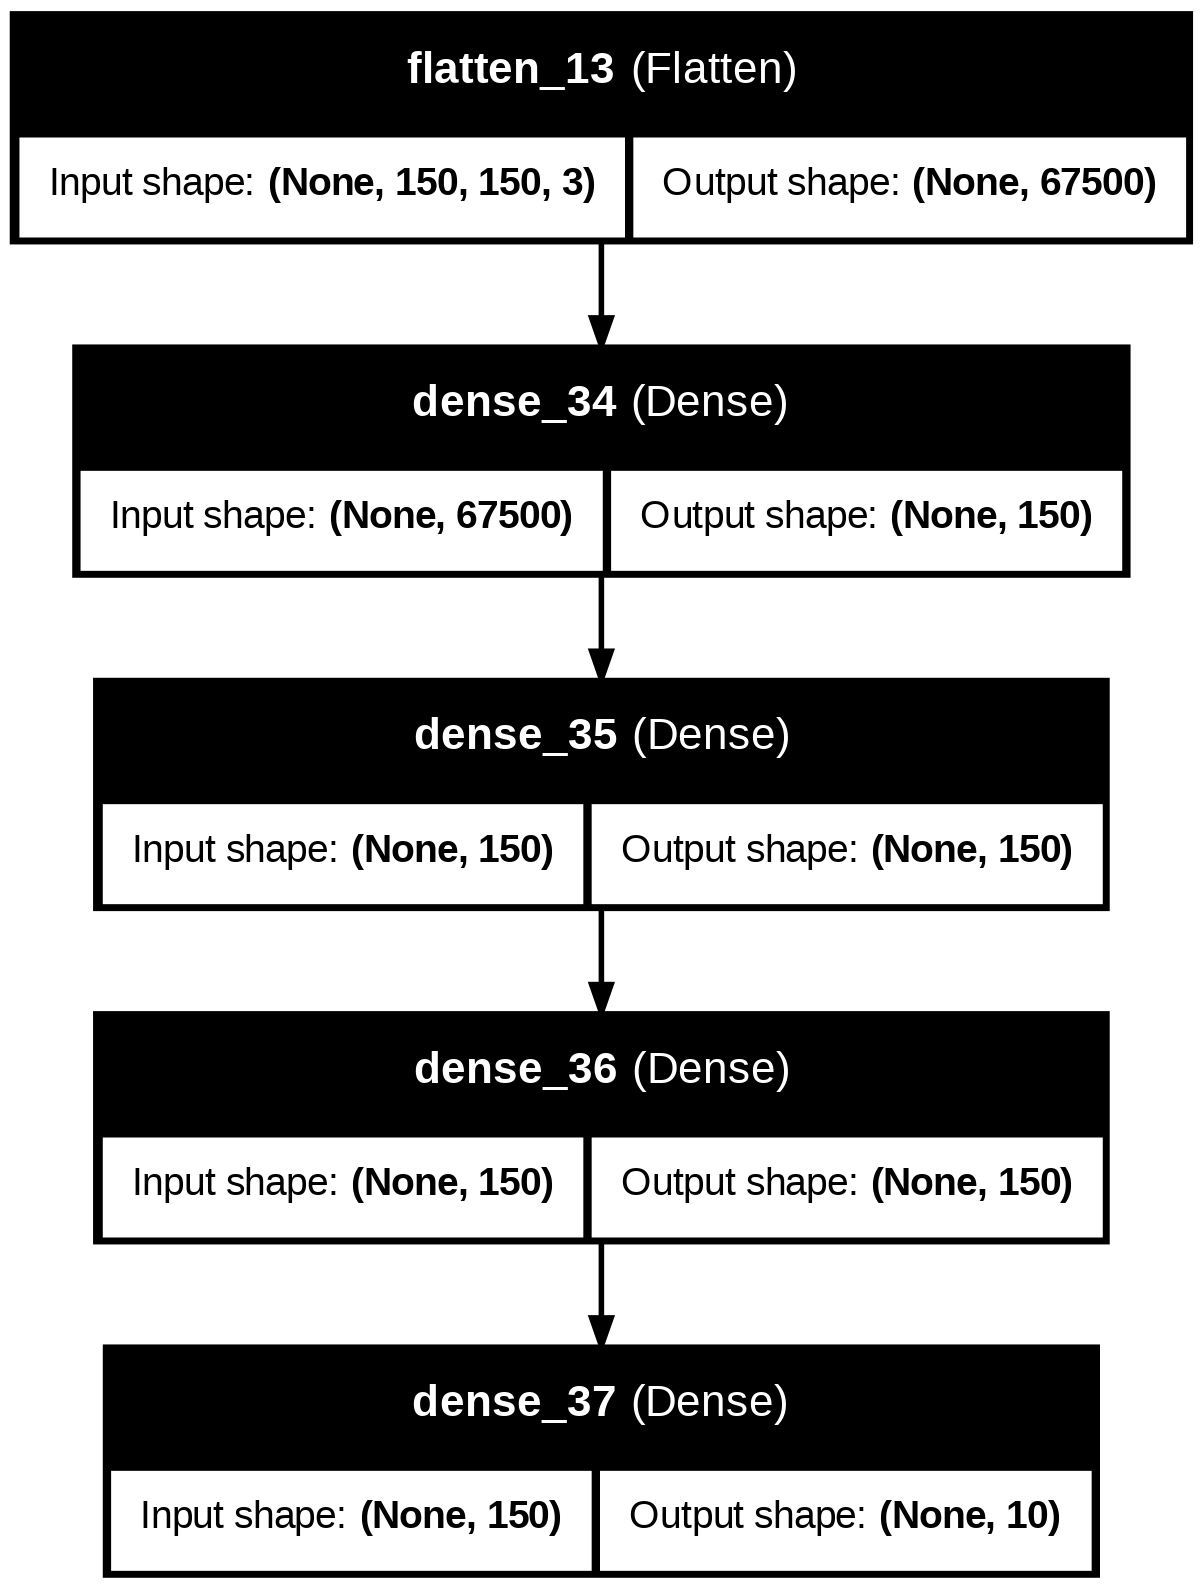

In [ ]:
tf.keras.utils.plot_model(
   model2,
   show_shapes=True,
   show_layer_names=True,
)

## Compiling the model

In [ ]:
adam_optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)
rmsprop_optimizer = tf.keras.optimizers.RMSprop(learning_rate=0.001)

model1.compile(
    optimizer=rmsprop_optimizer,
    loss=tf.keras.losses.sparse_categorical_crossentropy,
    metrics=['accuracy']
)

adam_optimizer2 = tf.keras.optimizers.Adam(learning_rate=0.001)
rmsprop_optimizer2 = tf.keras.optimizers.RMSprop(learning_rate=0.001)
## TODO: also repeat this compile code for the simple neural network model
model2.compile(
    optimizer=rmsprop_optimizer2,
    loss=tf.keras.losses.sparse_categorical_crossentropy,
    metrics=['accuracy']
)

## Data shuffling and batching

We don't want our model to learn anything from the order or grouping of the images in the dataset. To avoid that we will shuffle the training examples.

In [ ]:
BATCH_SIZE = 32
dataset_train_shuffled = dataset_train.shuffle(buffer_size=1000).batch(BATCH_SIZE)
dataset_validation_shuffled = dataset_validation.batch(BATCH_SIZE)

In [ ]:
print(dataset_train_shuffled)
print(dataset_validation_shuffled)

<_BatchDataset element_spec=(TensorSpec(shape=(None, 150, 150, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int64, name=None))>
<_BatchDataset element_spec=(TensorSpec(shape=(None, 150, 150, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int64, name=None))>


## Training the model

In [ ]:
!rm -rf tmp/checkpoints
!rm -rf logs

In [ ]:
training_history1 = model1.fit(
    x=dataset_train_shuffled,
    validation_data=dataset_validation_shuffled,
    epochs=15
)

Epoch 1/15
15/15 ━━━━━━━━━━━━━━━━━━━━ 59s 4s/step - accuracy: 0.3305 - loss: 1.2217 - val_accuracy: 0.4454 - val_loss: 1.0845
Epoch 2/15
15/15 ━━━━━━━━━━━━━━━━━━━━ 42s 3s/step - accuracy: 0.3941 - loss: 1.0958 - val_accuracy: 0.2857 - val_loss: 1.0941
Epoch 3/15
15/15 ━━━━━━━━━━━━━━━━━━━━ 87s 3s/step - accuracy: 0.3708 - loss: 1.1309 - val_accuracy: 0.5378 - val_loss: 1.0424
Epoch 4/15
15/15 ━━━━━━━━━━━━━━━━━━━━ 51s 3s/step - accuracy: 0.4809 - loss: 1.0306 - val_accuracy: 0.6639 - val_loss: 0.7502
Epoch 5/15
15/15 ━━━━━━━━━━━━━━━━━━━━ 45s 3s/step - accuracy: 0.6610 - loss: 0.7069 - val_accuracy: 0.7647 - val_loss: 0.5536
Epoch 6/15
15/15 ━━━━━━━━━━━━━━━━━━━━ 41s 3s/step - accuracy: 0.7669 - loss: 0.5465 - val_accuracy: 0.9076 - val_loss: 0.2486
Epoch 7/15
15/15 ━━━━━━━━━━━━━━━━━━━━ 85s 3s/step - accuracy: 0.8814 - loss: 0.2882 - val_accuracy: 0.8992 - val_loss: 0.3843
Epoch 8/15
15/15 ━━━━━━━━━━━━━━━━━━━━ 44s 3s/step - accuracy: 0.9428 - loss: 0.1866 - val_accuracy: 0.9664 - val_loss:

In [ ]:
## TODO: also repeat this training code for the simple neural network model and call it training_history2

training_history2 = model2.fit(
    x=dataset_train_shuffled,
    validation_data=dataset_validation_shuffled,
    epochs=15
)

Epoch 1/15
15/15 ━━━━━━━━━━━━━━━━━━━━ 7s 398ms/step - accuracy: 0.2987 - loss: 43.7392 - val_accuracy: 0.2689 - val_loss: 15.6676
Epoch 2/15
15/15 ━━━━━━━━━━━━━━━━━━━━ 4s 226ms/step - accuracy: 0.3517 - loss: 18.1153 - val_accuracy: 0.2689 - val_loss: 9.2874
Epoch 3/15
15/15 ━━━━━━━━━━━━━━━━━━━━ 3s 218ms/step - accuracy: 0.3347 - loss: 8.4060 - val_accuracy: 0.4454 - val_loss: 4.7633
Epoch 4/15
15/15 ━━━━━━━━━━━━━━━━━━━━ 4s 227ms/step - accuracy: 0.3581 - loss: 4.3110 - val_accuracy: 0.4454 - val_loss: 3.2110
Epoch 5/15
15/15 ━━━━━━━━━━━━━━━━━━━━ 6s 278ms/step - accuracy: 0.3199 - loss: 3.3915 - val_accuracy: 0.4454 - val_loss: 3.8337
Epoch 6/15
15/15 ━━━━━━━━━━━━━━━━━━━━ 3s 213ms/step - accuracy: 0.3792 - loss: 3.6406 - val_accuracy: 0.4454 - val_loss: 3.4285
Epoch 7/15
15/15 ━━━━━━━━━━━━━━━━━━━━ 4s 230ms/step - accuracy: 0.3792 - loss: 3.2669 - val_accuracy: 0.4454 - val_loss: 3.0764
Epoch 8/15
15/15 ━━━━━━━━━━━━━━━━━━━━ 5s 347ms/step - accuracy: 0.3729 - loss: 3.2291 - val_accuracy:

In [ ]:
# accuracy per category
import numpy as np
from collections import defaultdict

# initialize counters
correct_per_class = defaultdict(int)
total_per_class = defaultdict(int)

# loop through validation dataset
for images, labels in dataset_validation_shuffled:
    predictions = model1.predict(images)
    predicted_labels = np.argmax(predictions, axis=1)
    true_labels = labels.numpy()

    for true, pred in zip(true_labels, predicted_labels):
        total_per_class[true] += 1
        if true == pred:
            correct_per_class[true] += 1

# print accuracy per class
for class_idx in range(len(unique_labels)):
    correct = correct_per_class[class_idx]
    total = total_per_class[class_idx]
    acc = correct / total if total > 0 else 0
    print(f"Accuracy for class '{unique_labels[class_idx]}': {acc:.2f}")


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 842ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 650ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 588ms/step
Accuracy for class 'paper': 0.97
Accuracy for class 'rock': 1.00
Accuracy for class 'scissors': 1.00


In [ ]:
## TODO: also repeat this accuracy per category code for the simple neural network model

# initialize counters
correct_per_class = defaultdict(int)
total_per_class = defaultdict(int)

# loop through validation dataset
for images, labels in dataset_validation_shuffled:
    predictions = model2.predict(images)
    predicted_labels = np.argmax(predictions, axis=1)
    true_labels = labels.numpy()

    for true, pred in zip(true_labels, predicted_labels):
        total_per_class[true] += 1
        if true == pred:
            correct_per_class[true] += 1

# print accuracy per class
for class_idx in range(len(unique_labels)):
    correct = correct_per_class[class_idx]
    total = total_per_class[class_idx]
    acc = correct / total if total > 0 else 0
    print(f"Accuracy for class '{unique_labels[class_idx]}': {acc:.2f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step
Accuracy for class 'paper': 0.00
Accuracy for class 'rock': 1.00
Accuracy for class 'scissors': 0.00


In [ ]:
def render_training_history(training_history):
    loss = training_history.history['loss']
    val_loss = training_history.history['val_loss']

    accuracy = training_history.history['accuracy']
    val_accuracy = training_history.history['val_accuracy']

    plt.figure(figsize=(14, 4))

    plt.subplot(1, 2, 1)
    plt.title('Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.plot(loss, label='Training set')
    plt.plot(val_loss, label='Test set', linestyle='--')
    plt.legend()
    plt.grid(linestyle='--', linewidth=1, alpha=0.5)

    plt.subplot(1, 2, 2)
    plt.title('Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.plot(accuracy, label='Training set')
    plt.plot(val_accuracy, label='Test set', linestyle='--')
    plt.legend()
    plt.grid(linestyle='--', linewidth=1, alpha=0.5)

    plt.show()

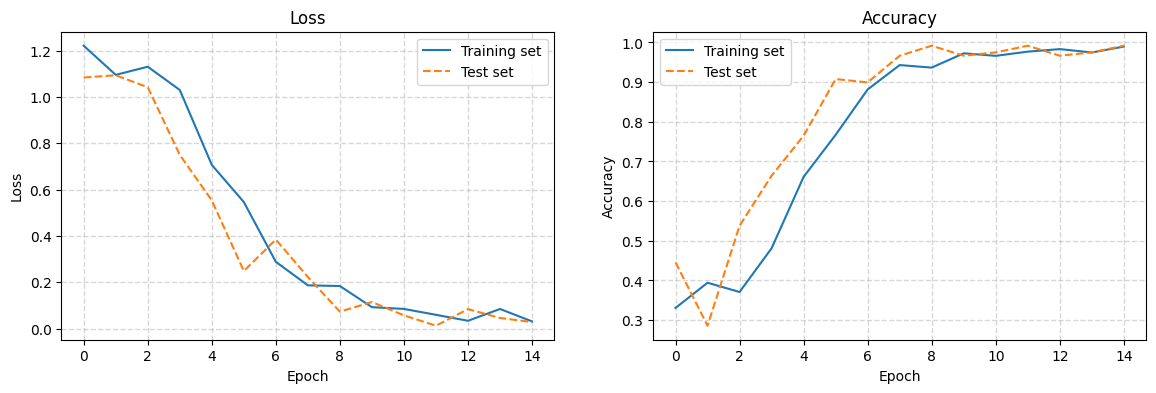

In [ ]:
render_training_history(training_history1)

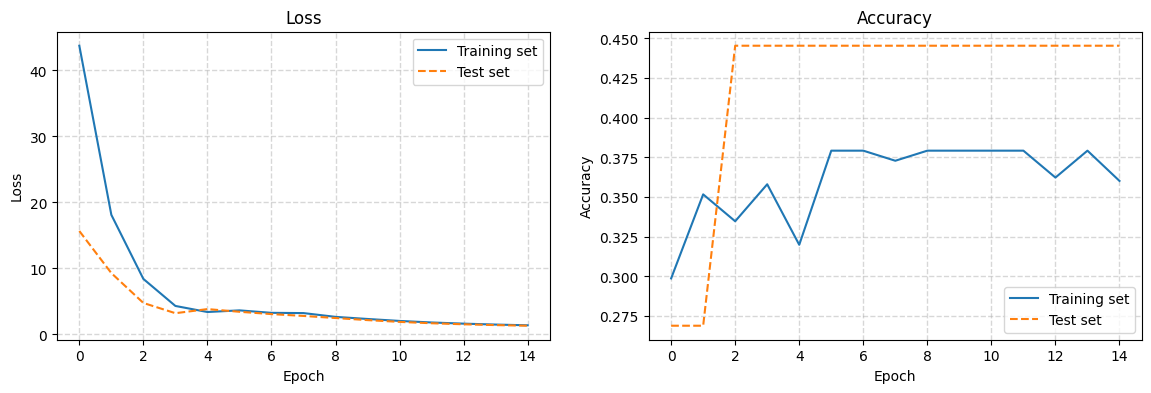

In [ ]:
## TODO: also call this function for the simple neural network model's training history (training_history2)
## ADD YOUR CODE HERE

render_training_history(training_history2)

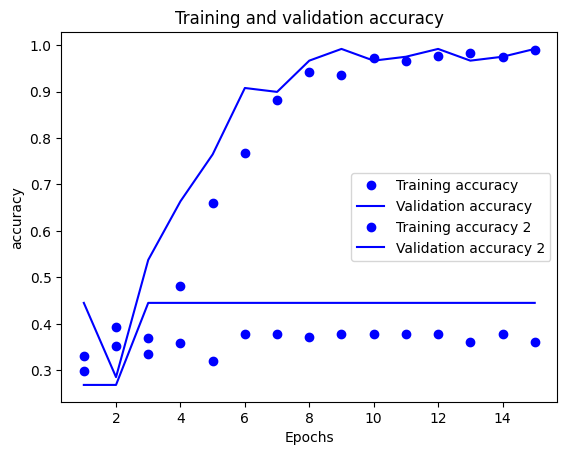

In [ ]:
## TODO: plot the training accuracy and validation accuracy of both models in the same figure to compare the results

import matplotlib.pyplot as plt
history_dict = training_history1.history
accuracy_values = history_dict["accuracy"]
val_accuracy_values = history_dict["val_accuracy"]
epochs = range(1, len(accuracy_values) + 1)
plt.plot(epochs, accuracy_values, "bo", label="Training accuracy")
plt.plot(epochs, val_accuracy_values, "b", label="Validation accuracy")

history_dict2 = training_history2.history
accuracy_values = history_dict2["accuracy"]
val_accuracy_values = history_dict2["val_accuracy"]
epochs = range(1, len(accuracy_values) + 1)
plt.plot(epochs, accuracy_values, "bo", label="Training accuracy 2")
plt.plot(epochs, val_accuracy_values, "b", label="Validation accuracy 2")

plt.title("Training and validation accuracy")
plt.xlabel("Epochs")
plt.ylabel("accuracy")
plt.legend()
plt.show()



## Evaluating model accuracy

In [ ]:
# %%capture
train_loss1, train_accuracy1 = model1.evaluate(
    x=dataset_train.batch(BATCH_SIZE).take(NUM_TRAIN_EXAMPLES)
)

validation_loss1, validation_accuracy1 = model1.evaluate(
    x=dataset_validation.batch(BATCH_SIZE).take(NUM_VALIDATION_EXAMPLES)
)

15/15 ━━━━━━━━━━━━━━━━━━━━ 12s 824ms/step - accuracy: 0.9958 - loss: 0.0096
4/4 ━━━━━━━━━━━━━━━━━━━━ 3s 801ms/step - accuracy: 0.9916 - loss: 0.0278


In [ ]:
print('training loss:', train_loss1)
print('training accuracy:', train_accuracy1)
print()
print('validation loss:', validation_loss1)
print('validation accuracy:', validation_accuracy1)

training loss: 0.009609563276171684
training accuracy: 0.9957627058029175

validation loss: 0.02784891612827778
validation accuracy: 0.9915966391563416


In [ ]:
## TODO: also repeat this evaluation code for the simple neural network model and call the outputs with index 2
train_loss2, train_accuracy2 = model2.evaluate(
    x=dataset_train.batch(BATCH_SIZE).take(NUM_TRAIN_EXAMPLES)
)

validation_loss2, validation_accuracy2 = model2.evaluate(
    x=dataset_validation.batch(BATCH_SIZE).take(NUM_VALIDATION_EXAMPLES)
)

15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 69ms/step - accuracy: 0.3792 - loss: 1.3272
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - accuracy: 0.4454 - loss: 1.3145


## Saving the model

In [ ]:
%cd '/content'
model_name1 = 'DEEP_rock_paper_scissors_cnn.keras'
model_name2 = 'DEEP_rock_paper_scissors_ann.keras'

## TODO: try out different hyperparameters and find the best one with the highest validation accuracy
## TODO: pick your best overall model to save here (check all different parameters for model1 and model2)
model1.save(model_name1)
model2.save(model_name2)

model1.save(model_name1, save_format="h5")
model2.save(model_name2, save_format="h5")

/content


## Testing the model

Add test photos of your choice into a folder called "test" in the Colab directory to the left of this page. Run the code below to check the prediction of your model on the photos.

In [ ]:
import os
import numpy as np
import tensorflow as tf
from PIL import Image

# load the trained model
model_path = '/content/DEEP_rock_paper_scissors_cnn.keras'
model = tf.keras.models.load_model(model_path)

# label list from training time
unique_labels = ['paper', 'rock', 'scissors']  # replace with your actual labels

# create index to label mapping
index_to_label = {i: label for i, label in enumerate(unique_labels)}
def get_label_name(pred_index):
    return index_to_label[pred_index]

# test folder path
test_dir = '/content/test'

# confirm expected model input shape
print("model expects input shape:", model.input_shape)

def preprocess_image(image_path, target_size=(INPUT_IMG_SIZE, INPUT_IMG_SIZE)):
    image = Image.open(image_path).convert('RGB')
    image = image.resize(target_size)
    image_array = np.array(image, dtype=np.float32) / 255.0
    return image_array

for filename in os.listdir(test_dir):
    if filename.lower().endswith(('.jpg', '.jpeg', '.png')):
        image_path = os.path.join(test_dir, filename)
        image = preprocess_image(image_path)
        input_tensor = tf.expand_dims(image, axis=0)  # shape: (1, INPUT_IMG_SIZE, INPUT_IMG_SIZE, 3)

        predictions = model(input_tensor)
        predicted_index = tf.argmax(predictions[0]).numpy()
        predicted_label = get_label_name(predicted_index)

        print(f"{filename} → {predicted_label} (confidence: {predictions[0][predicted_index]:.2f})")


model expects input shape: (None, 150, 150, 3)


FileNotFoundError: [Errno 2] No such file or directory: '/content/test'

In [ ]:
model_path = '/content/DEEP_rock_paper_scissors_cnn.keras'
model = tf.keras.models.load_model(model_path)

In [ ]:
from IPython.display import display, Javascript
from google.colab.output import eval_js
from base64 import b64decode
import numpy as np
import tensorflow as tf
from PIL import Image

def take_photo(filename='/content/camera_photo.jpg', quality=0.8):
    js = Javascript('''
        async function takePhoto(quality) {
            const div = document.createElement('div');
            const capture = document.createElement('button');
            capture.textContent = 'Capture';
            div.appendChild(capture);

            const video = document.createElement('video');
            video.style.display = 'block';
            const stream = await navigator.mediaDevices.getUserMedia({video: true});

            document.body.appendChild(div);
            div.appendChild(video);
            video.srcObject = stream;
            await video.play();

            // Resize the output to fit the video element.
            google.colab.output.setIframeHeight(document.documentElement.scrollHeight, true);

            // Wait for Capture to be clicked.
            await new Promise((resolve) => capture.onclick = resolve);

            const canvas = document.createElement('canvas');
            canvas.width = video.videoWidth;
            canvas.height = video.videoHeight;
            canvas.getContext('2d').drawImage(video, 0, 0);
            stream.getVideoTracks()[0].stop();
            div.remove();
            return canvas.toDataURL('image/jpeg', quality);
        }
        ''')
    display(js)
    data = eval_js('takePhoto({})'.format(quality))
    binary = b64decode(data.split(',')[1])
    with open(filename, 'wb') as f:
        f.write(binary)
    return filename


def predict_from_camera():
    # capture photo from webcam
    photo_path = take_photo()

    # preprocess the captured photo (same as your test cell)
    image = Image.open(photo_path).convert('RGB')
    image = image.resize((INPUT_IMG_SIZE, INPUT_IMG_SIZE))
    image_array = np.array(image, dtype=np.float32) / 255.0
    input_tensor = tf.expand_dims(image_array, axis=0)

    # predict
    predictions = model(input_tensor)
    predicted_index = tf.argmax(predictions[0]).numpy()
    predicted_label = get_label_name(predicted_index)
    confidence = predictions[0][predicted_index].numpy()

    # show the captured image with the prediction
    plt.figure(figsize=(4, 4))
    plt.imshow(Image.open(photo_path))
    plt.axis('off')
    plt.title(f"Prediction: {predicted_label} ({confidence:.2f})")
    plt.show()

    return predicted_label, confidence


# run it
# predict_from_camera()

In [ ]:
import numpy as np
import tensorflow as tf
from PIL import Image
import matplotlib.pyplot as plt

def test_model_with_camera(num_images=10):
    true_labels = []
    predicted_labels = []
    images_for_display = []

    print(f"Available labels: {unique_labels}\n")

    for i in range(1, num_images + 1):
        print(f"\n=== Image {i} of {num_images} ===")

        # ask for the true label
        true_label = input(f"Enter the true label for this image {unique_labels}: ").strip().lower()
        while true_label not in unique_labels:
            print(f"Invalid label. Please choose from: {unique_labels}")
            true_label = input(f"Enter the true label for this image {unique_labels}: ").strip().lower()

        # capture photo
        input("Press Enter, then show your gesture to the camera and click Capture...")
        photo_path = take_photo(filename=f'/content/camera_test_{i}.jpg')

        # preprocess (same pipeline as training/prediction)
        image = Image.open(photo_path).convert('RGB')
        image_resized = image.resize((INPUT_IMG_SIZE, INPUT_IMG_SIZE))
        image_array = np.array(image_resized, dtype=np.float32) / 255.0
        input_tensor = tf.expand_dims(image_array, axis=0)

        # predict
        predictions = model(input_tensor)
        predicted_index = tf.argmax(predictions[0]).numpy()
        predicted_label = get_label_name(predicted_index)
        confidence = predictions[0][predicted_index].numpy()

        # store results
        true_labels.append(true_label)
        predicted_labels.append(predicted_label)
        images_for_display.append(image)

        correct = "✅" if predicted_label == true_label else "❌"
        print(f"True: {true_label} | Predicted: {predicted_label} (confidence: {confidence:.2f}) {correct}")

    # calculate overall accuracy
    correct_count = sum(t == p for t, p in zip(true_labels, predicted_labels))
    accuracy = correct_count / num_images

    print(f"\n=== Test Results ===")
    print(f"Correct: {correct_count}/{num_images}")
    print(f"Accuracy: {accuracy:.2%}")

    # display all captured images with true vs predicted labels
    plt.figure(figsize=(15, 6))
    for idx, (img, true_l, pred_l) in enumerate(zip(images_for_display, true_labels, predicted_labels)):
        plt.subplot(2, 5, idx + 1)
        plt.imshow(img)
        plt.axis('off')
        color = 'green' if true_l == pred_l else 'red'
        plt.title(f"T: {true_l}\nP: {pred_l}", color=color, fontsize=10)
    plt.tight_layout()
    plt.show()

    return true_labels, predicted_labels, accuracy


# run it
true_labels, predicted_labels, accuracy = test_model_with_camera(num_images=10)